# Comparing Survival Models with `az.loo` and `az.compare`

Every model in this library answers the same question — *how long until the event?* — but they
disagree about the shape of the answer. A Weibull AFT insists the hazard is monotonic. A
log-logistic AFT allows it to peak and fall. A piecewise Cox model refuses to commit to any
parametric shape. A mixture cure model says some subjects never experience the event at all.

Given one dataset, which of those stories fits best?

**Leave-one-out cross-validation (LOO)** answers this. It estimates how well each model predicts
observations it has not seen, then ranks the candidates. ArviZ implements it as `az.loo` for a
single model and `az.compare` for a field of them.

Every `fit()` in this library attaches the pointwise log-likelihood needed for this, so the
workflow is simply: fit, collect the `InferenceData` objects, compare.

This notebook runs that workflow on **two datasets generated by the same process**, differing
only in whether a cured subpopulation exists. The ranking changes between them — which is the
point. LOO responds to the data rather than rewarding whichever model has the most parameters.

> The mechanics that make these numbers comparable across model families — and the ways a naive
> setup silently produces wrong rankings — are written up in
> [`notes/Model_Comparison.md`](../notes/Model_Comparison.md).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import arviz as az

from bayes_survival import (
    WeibullAFTModel, LogNormalAFTModel, LogLogisticAFTModel,
    PiecewiseCoxPHModel,
    LogNormalCureModel, WeibullCureModel, LogLogisticCureModel,
)

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
az.style.use('arviz-white')

## 1. The Synthetic Returns Dataset

The same e-commerce returns scenario used in
[`Cure_Introduction.ipynb`](Cure_Introduction.ipynb): customers buy an item, and we observe how
long until they return it, right-censored at 30 days.

The generator is wrapped in a function with a single `cure` flag, because we will need it twice:

- **`cure=True`** — the process that actually generated the data in the cure notebook. Each
  customer is either *susceptible* (will eventually return) with probability
  $\pi(x) = \mathrm{sigmoid}(\alpha + X\beta)$, or **cured** and never returns. Susceptible
  customers get a log-logistic return time.
- **`cure=False`** — identical in every other respect, but *everyone* is susceptible. No cured
  subpopulation exists.

Holding the covariates, the timing distribution and the censoring rule fixed means any change in
the model ranking between the two is attributable to the cure fraction alone.

In [2]:
def make_returns_data(cure=True, n=1000, T=30, seed=42):
    # Synthetic e-commerce returns. If cure=False, every customer is susceptible.
    np.random.seed(seed)

    # ── covariates ────────────────────────────────────────────────────────────
    log_price = np.random.normal(4, 0.8, n)        # log(price in GBP), mean ~ 55
    category  = np.random.binomial(1, 0.4, n)      # 1 = apparel (40%)
    premium   = np.random.binomial(1, 0.25, n)     # 1 = premium customer (25%)
    X = np.column_stack([log_price, category, premium])

    # ── who is susceptible to returning at all? ───────────────────────────────
    pi_true = stats.logistic.cdf(-0.8 + X @ np.array([-0.3, 1, 2]))
    susceptible = np.random.binomial(1, pi_true) if cure else np.ones(n, dtype=int)

    # ── log-logistic return times for the susceptible ─────────────────────────
    lam_true = np.exp(1.95 + X @ np.array([0.2, -0.5, -0.4]))
    U = np.random.uniform(size=n)
    t_latent = lam_true * (U / (1.0 - U)) ** (1.0 / 3.0)

    # ── right-censor at T days ────────────────────────────────────────────────
    observed = susceptible.astype(bool) & (t_latent <= T)
    t_obs = np.where(observed, t_latent, float(T))
    event = observed.astype(float)

    return X, t_obs, event, pi_true


X_A, t_A, event_A, pi_A = make_returns_data(cure=True)

print('Dataset A  (cured subpopulation present)')
print(f'  observations        : {len(t_A)}')
print(f'  events (returns)    : {int(event_A.sum())} ({event_A.mean():.1%})')
print(f'  true cure fraction  : {1 - pi_A.mean():.1%}')
print(f'  time range          : {t_A.min():.2f} - {t_A.max():.0f} days')

Dataset A  (cured subpopulation present)
  observations        : 1000
  events (returns)    : 265 (26.5%)
  true cure fraction  : 71.8%
  time range          : 0.72 - 30 days


## 2. Fitting the Model Zoo

Seven models spanning every family the library implements:

| Family | Models | What it assumes |
|---|---|---|
| AFT | `WeibullAFTModel`, `LogNormalAFTModel`, `LogLogisticAFTModel` | Covariates stretch or compress the time axis |
| Cox | `PiecewiseCoxPHModel` | Covariates multiply a flexible, non-parametric baseline hazard |
| Mixture cure | `LogNormalCureModel`, `WeibullCureModel`, `LogLogisticCureModel` | A latent subgroup never experiences the event |

`fit()` attaches the pointwise `log_likelihood` group by default, so nothing extra is needed
here — collecting each model's `idata` is enough. (Pass `log_likelihood=False` to skip the
computation if you do not intend to compare.)

In [3]:
FIT_KW = dict(draws=1000, tune=1000, chains=4, random_seed=42, progressbar=False)

def build_zoo():
    return {
        'weibull_aft'      : WeibullAFTModel(),
        'lognormal_aft'    : LogNormalAFTModel(),
        'loglogistic_aft'  : LogLogisticAFTModel(),
        'piecewise_cox'    : PiecewiseCoxPHModel(n_intervals=8),
        'lognormal_cure'   : LogNormalCureModel(),
        'weibull_cure'     : WeibullCureModel(),
        'loglogistic_cure' : LogLogisticCureModel(),
    }

def fit_zoo(X, t, event):
    out = {}
    for name, model in build_zoo().items():
        model.fit(X, t, event, **FIT_KW)
        out[name] = model.idata
    return out

idatas_A = fit_zoo(X_A, t_A, event_A)

# Every fit carries a pointwise log_likelihood of shape (chains, draws, n_obs)
for name, idata in idatas_A.items():
    print(f'{name:18s} log_likelihood {tuple(idata.log_likelihood["obs"].shape)}')

weibull_aft        log_likelihood (4, 1000, 1000)
lognormal_aft      log_likelihood (4, 1000, 1000)
loglogistic_aft    log_likelihood (4, 1000, 1000)
piecewise_cox      log_likelihood (4, 1000, 1000)
lognormal_cure     log_likelihood (4, 1000, 1000)
weibull_cure       log_likelihood (4, 1000, 1000)
loglogistic_cure   log_likelihood (4, 1000, 1000)


## 3. Reading a Single Model's LOO

`az.loo` summarises one model's out-of-sample predictive performance.

- **`elpd_loo`** — expected log pointwise predictive density. Higher (less negative) is better.
  On its own the number is meaningless; it only carries information *relative to another model
  scored on the same observations*.
- **`se`** — standard error of that estimate across observations.
- **`p_loo`** — the effective number of parameters. Read it as a complexity measure: it should
  land near the model's actual parameter count, and a wildly inflated value is a red flag.

In [4]:
loo_ll_cure = az.loo(idatas_A['loglogistic_cure'])
print(loo_ll_cure)

Computed from 4000 posterior samples and 1000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1268.33    56.54
p_loo        8.55        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1000  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



`p_loo` tracks how flexible each model is. The AFT models carry an intercept, three
coefficients and one shape parameter; the piecewise Cox model additionally carries eight
baseline-hazard values tied together by a random walk, and its `p_loo` is correspondingly
larger:

In [5]:
rows = []
for name, idata in idatas_A.items():
    loo = az.loo(idata)
    rows.append({'model': name, 'elpd_loo': loo.elpd_loo, 'se': loo.se, 'p_loo': loo.p_loo})

pd.DataFrame(rows).set_index('model').round(2)

,elpd_loo,se,p_loo
model,,,
weibull_aft,-1348.26,58.56,4.93
lognormal_aft,-1326.42,57.25,4.72
loglogistic_aft,-1333.73,57.60,4.85
piecewise_cox,-1290.09,58.12,10.64
lognormal_cure,-1273.46,57.24,9.72
weibull_cure,-37907282.75,6554662.84,37905944.58
loglogistic_cure,-1268.33,56.54,8.55


## 4. Comparing Models with `az.compare`

`az.compare` takes a `{name: InferenceData}` mapping and ranks the field.

| Column | Meaning |
|---|---|
| `rank` | 0 is the best-scoring model |
| `elpd_loo` | the estimate from `az.loo` |
| `p_loo` | effective number of parameters |
| `elpd_diff` | gap to the rank-0 model |
| `weight` | stacking weight — how much to lean on this model when *blending* predictions |
| `se` | standard error of `elpd_loo` |
| `dse` | standard error **of the difference** to the rank-0 model |
| `warning` | the diagnostics for this row are unreliable — investigate before trusting it |

In [6]:
compare_A = az.compare(idatas_A)
compare_A.round(2)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
loglogistic_cure,0,-1268.33,8.55,0.00,0.55,56.54,0.00,False,log
lognormal_cure,1,-1273.46,9.72,5.13,0.00,57.24,4.89,False,log
piecewise_cox,2,-1290.09,10.64,21.76,0.45,58.12,19.92,False,log
lognormal_aft,3,-1326.42,4.72,58.09,0.00,57.25,9.57,False,log
loglogistic_aft,4,-1333.73,4.85,65.40,0.00,57.60,10.43,False,log
weibull_aft,5,-1348.26,4.93,79.93,0.00,58.56,11.72,False,log
weibull_cure,6,-37907282.75,37905944.58,37906014.41,0.00,6554662.84,6554637.45,True,log


Three things in that table matter more than the ordering itself.

**`dse`, not `elpd_diff`, tells you whether a gap is real.** A difference is only convincing
when it is large relative to its own standard error — roughly, when `elpd_diff` exceeds about
twice `dse`. Comparing the top two models here:

In [7]:
top2 = compare_A.index[:2]
diff = compare_A.loc[top2[1], 'elpd_diff']
dse  = compare_A.loc[top2[1], 'dse']
print(f'{top2[0]}  vs  {top2[1]}')
print(f'  elpd_diff = {diff:.2f}')
print(f'  dse       = {dse:.2f}')
print(f'  ratio     = {diff / dse:.2f}   -> {"separable" if diff > 2 * dse else "NOT separable"}')

best_aft = compare_A.loc[[i for i in compare_A.index if i.endswith("_aft")]].index[0]
diff_aft = compare_A.loc[best_aft, 'elpd_diff']
dse_aft  = compare_A.loc[best_aft, 'dse']
print()
print(f'{top2[0]}  vs  {best_aft} (best plain AFT)')
print(f'  elpd_diff = {diff_aft:.2f}')
print(f'  dse       = {dse_aft:.2f}')
print(f'  ratio     = {diff_aft / dse_aft:.2f}   -> {"separable" if diff_aft > 2 * dse_aft else "NOT separable"}')

loglogistic_cure  vs  lognormal_cure
  elpd_diff = 5.13
  dse       = 4.89
  ratio     = 1.05   -> NOT separable

loglogistic_cure  vs  lognormal_aft (best plain AFT)
  elpd_diff = 58.09
  dse       = 9.57
  ratio     = 6.07   -> separable


So the two cure models at the top are **statistically indistinguishable** from each other — the
visible gap in the table is smaller than the uncertainty in that gap. What the comparison *does*
establish decisively is that the cure models beat the plain AFT models. That is the honest
reading: LOO has identified the right *family*, not the single best model.

**`weight` answers a different question from `rank`.** Stacking weights are the optimal blend
for combining these models into one predictive distribution, so they concentrate on models that
contribute *complementary* information. A model can rank second yet receive almost no weight
because a higher-ranked model already covers what it does.

In [8]:
compare_A[['rank', 'elpd_loo', 'weight']].round(3)

,rank,elpd_loo,weight
loglogistic_cure,0,-1.268332e+03,0.555
lognormal_cure,1,-1.273464e+03,0.000
piecewise_cox,2,-1.290089e+03,0.445
lognormal_aft,3,-1.326422e+03,0.000
loglogistic_aft,4,-1.333728e+03,0.000
weibull_aft,5,-1.348263e+03,0.000
weibull_cure,6,-3.790728e+07,0.000


## 5. Diagnosing an Unreliable Model

One row in the table above carries `warning = True` and an `elpd_loo` several orders of
magnitude worse than everything else. `az.compare` ranked it anyway — it will happily sort a
model whose numbers cannot be trusted. Diagnosing that is your job, not the function's.

The diagnostic is the **Pareto $k$** statistic, available per observation via
`az.loo(..., pointwise=True)`. LOO avoids refitting the model $n$ times by reweighting the
existing posterior draws, and $k$ measures whether that reweighting is trustworthy for each
observation. Values above **0.7** mean it is not.

In [9]:
rows = []
for name, idata in idatas_A.items():
    loo = az.loo(idata, pointwise=True)
    k = np.asarray(loo.pareto_k)
    rows.append({
        'model'       : name,
        'elpd_loo'    : loo.elpd_loo,
        'max_k'       : k.max(),
        'n_k_above_.7': int((k > 0.7).sum()),
        'divergences' : int(idata.sample_stats['diverging'].values.sum()),
    })

pd.DataFrame(rows).set_index('model').round(2)

,elpd_loo,max_k,n_k_above_.7,divergences
model,,,,
weibull_aft,-1348.26,0.25,0,0
lognormal_aft,-1326.42,0.17,0,0
loglogistic_aft,-1333.73,0.17,0,0
piecewise_cox,-1290.09,0.11,0,0
lognormal_cure,-1273.46,0.22,0,0
weibull_cure,-37907282.75,inf,228,246
loglogistic_cure,-1268.33,0.20,0,0


`weibull_cure` fails on both counts: hundreds of observations above the $k$ threshold, and a
large number of divergent transitions during sampling. Those two findings reinforce each other
— the divergences say the posterior itself was not explored reliably, so the LOO estimate built
on top of it was never going to be meaningful.

The lesson generalises beyond this one model: **check sampling diagnostics before reading a
comparison table**. A model that did not sample properly will still be assigned a rank.

Its presence also makes the standard comparison plot unreadable, since a single point far off
the scale flattens every other model into a line. Drop it and compare the remaining six:

In [10]:
idatas_A_clean = {k: v for k, v in idatas_A.items() if k != 'weibull_cure'}
compare_A_clean = az.compare(idatas_A_clean)
compare_A_clean.round(2)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
loglogistic_cure,0,-1268.33,8.55,0.00,0.55,56.54,0.00,False,log
lognormal_cure,1,-1273.46,9.72,5.13,0.00,57.24,4.89,False,log
piecewise_cox,2,-1290.09,10.64,21.76,0.45,58.12,19.92,False,log
lognormal_aft,3,-1326.42,4.72,58.09,0.00,57.25,9.57,False,log
loglogistic_aft,4,-1333.73,4.85,65.40,0.00,57.60,10.43,False,log
weibull_aft,5,-1348.26,4.93,79.93,0.00,58.56,11.72,False,log


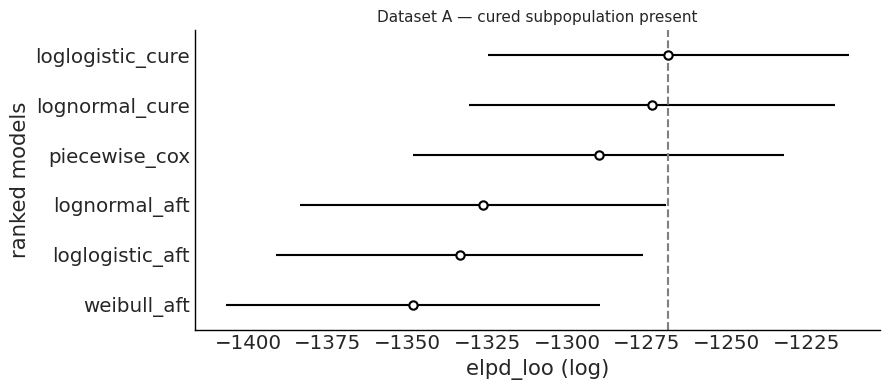

In [11]:
az.plot_compare(compare_A_clean, figsize=(9, 4))
plt.title('Dataset A — cured subpopulation present', fontsize=11)
plt.tight_layout()
plt.show()

Open circles are `elpd_loo` with its standard error; the triangles and thinner bars show the
difference to the best model. The dashed vertical line marks the top-ranked model. Where the
error bars overlap heavily, the models are not meaningfully distinguishable.

## 6. The Same Process Without a Cure Fraction

A ranking is only interesting if it could have come out differently. So far the cure models won
on data that genuinely contains cured customers — which is what should happen, but it does not
yet show that LOO is doing anything beyond preferring the most elaborate model.

Regenerate the dataset with `cure=False`. Same covariates, same log-logistic timing, same
censoring at 30 days — the only change is that every customer is now susceptible, so there is
no cured subpopulation for a cure model to find.

In [12]:
X_B, t_B, event_B, _ = make_returns_data(cure=False)

print('Dataset B  (no cured subpopulation)')
print(f'  observations     : {len(t_B)}')
print(f'  events (returns) : {int(event_B.sum())} ({event_B.mean():.1%})'
      f'   [dataset A: {event_A.mean():.1%}]')

idatas_B = fit_zoo(X_B, t_B, event_B)
compare_B = az.compare(idatas_B)
compare_B.round(2)

Dataset B  (no cured subpopulation)
  observations     : 1000
  events (returns) : 930 (93.0%)   [dataset A: 26.5%]


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
piecewise_cox,0,-2992.45,11.48,0.00,0.66,32.35,0.00,False,log
loglogistic_aft,1,-3067.48,4.90,75.03,0.00,23.21,33.47,False,log
loglogistic_cure,2,-3067.94,5.65,75.49,0.34,23.26,33.53,False,log
lognormal_aft,3,-3084.49,5.87,92.04,0.00,26.60,35.29,False,log
lognormal_cure,4,-3084.69,6.93,92.24,0.00,26.81,35.45,False,log
weibull_cure,5,-3098.44,9.58,105.99,0.00,22.89,33.54,False,log
weibull_aft,6,-3129.10,6.42,136.65,0.00,20.16,31.02,False,log


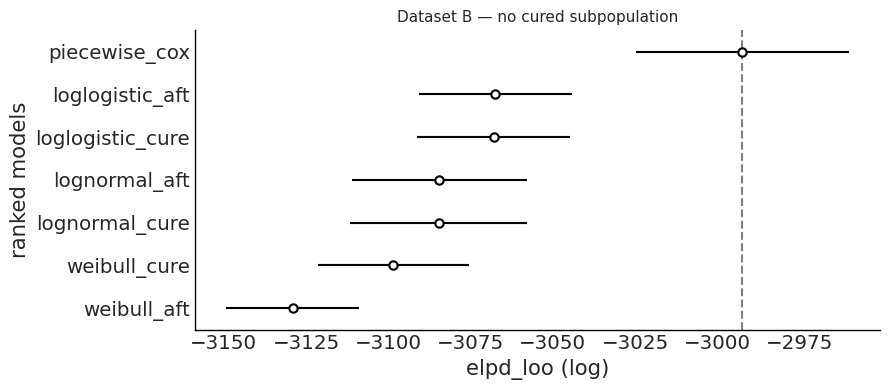

In [13]:
az.plot_compare(compare_B, figsize=(9, 4))
plt.title('Dataset B — no cured subpopulation', fontsize=11)
plt.tight_layout()
plt.show()

The winner has changed. `piecewise_cox` now leads, and the two cure models that held the top two
places on dataset A have fallen to ranks 2 and 4.

That the Cox model wins here is worth a moment's thought. With 93% of customers now returning
rather than 26.5%, there is far more information about the shape of the hazard and far less
censoring — which plays to a flexible piecewise baseline that commits to no parametric form. On
dataset A most of the data was censored survivors, and what mattered there was the cure
structure, not hazard flexibility.

The sharper signal is what happened *within* matched timing distributions. Each cure model sits
directly alongside the AFT model sharing its timing family:

In [14]:
pairs = [('loglogistic_aft', 'loglogistic_cure'),
         ('lognormal_aft',   'lognormal_cure'),
         ('weibull_aft',     'weibull_cure')]

print(f'{"timing":14s} {"AFT":>10s} {"cure":>10s} {"gap":>8s}')
for aft, cure in pairs:
    e_aft  = compare_B.loc[aft,  'elpd_loo']
    e_cure = compare_B.loc[cure, 'elpd_loo']
    print(f'{aft.split("_")[0]:14s} {e_aft:10.1f} {e_cure:10.1f} {e_aft - e_cure:+8.2f}')

timing                AFT       cure      gap
loglogistic       -3067.5    -3067.9    +0.46
lognormal         -3084.5    -3084.7    +0.20
weibull           -3129.1    -3098.4   -30.66


For log-logistic and log-normal timing the cure model now scores marginally *below* its AFT
counterpart. With no cured subpopulation to find, the logistic susceptibility sub-model has
nothing to explain — it collapses onto the plain AFT fit, and LOO charges it for the extra
parameters. The penalty is small because the parameters are few, but the direction is right.

**The Weibull pair goes the other way, and that is instructive.** `weibull_aft` is the worst
model on this data by a wide margin: the timing distribution is genuinely log-logistic, and a
Weibull tail cannot represent it. The cure fraction gives `weibull_cure` somewhere to put the
probability mass that the Weibull tail misplaces, so its extra flexibility earns its keep even
though no cured subpopulation exists.

The lesson is that a cure model beating its AFT twin is evidence about the *timing* fit, not
proof of a cure fraction. Read the comparison as ranking whole modelling choices, not as a test
of one feature.

Note also that `weibull_cure`, catastrophic on dataset A, sampled cleanly here — no divergences,
no Pareto $k$ warnings. Its instability was a property of that particular data and posterior
geometry, not a permanent defect of the model class. Diagnostics have to be checked per fit,
never assumed from experience.

Side by side:

In [15]:
side_by_side = pd.DataFrame({
    'rank on A (with cure)':    compare_A['rank'],
    'rank on B (without cure)': compare_B['rank'],
}).sort_values('rank on A (with cure)')

side_by_side

,rank on A (with cure),rank on B (without cure)
loglogistic_cure,0,2
lognormal_cure,1,4
piecewise_cox,2,0
lognormal_aft,3,3
loglogistic_aft,4,1
weibull_aft,5,6
weibull_cure,6,5


## 7. When a Comparison Is Not Valid

`az.compare` will rank whatever you hand it. It does not verify that the comparison means
anything, and it produces no warning when it does not. Four conditions have to hold, and you
are responsible for all of them.

**1. The same observations.** Every model must be scored on the identical dataset. Dropping
missing rows for one model, or fitting one on a subset, silently invalidates the comparison —
elpd is a sum over observations, so fewer observations means a mechanically higher score.

**2. The same measure.** A model fitted to $\log T$ reports the density of $\log T$, which is
not the density of $T$. Comparing it against a model fitted on the time scale compares two
different quantities and the difference is arbitrary. This library handles the conversion
internally for its log-scale models — see the notes linked below.

**3. The same aggregation level.** The log-likelihood must be one value per subject. A model
whose likelihood is defined over expanded rows — as the piecewise Cox model's is internally —
would otherwise be scored over a different number of pseudo-observations entirely. This library
folds those back to per-subject before reporting.

**4. Reliable diagnostics.** As section 5 showed: check Pareto $k$ and divergences first. A
badly sampled model still gets a rank.

One further caveat that applies even when all four hold: these models were compared on the same
data they were fitted to. LOO estimates out-of-sample performance rather than measuring it, and
that estimate degrades when a model is heavily over-parameterised relative to the sample. With
genuinely limited data, a held-out test set remains the stronger evidence.

> Points 2 and 3 are properties of *this library's* implementation. What they involve, and how a
> naive setup gets them silently wrong, is written up in
> [`notes/Model_Comparison.md`](../notes/Model_Comparison.md).

## Summary

| Tool | Use it for |
|---|---|
| `az.loo(idata)` | One model's `elpd_loo`, `se`, and `p_loo` |
| `az.loo(idata, pointwise=True)` | Per-observation Pareto $k$ — the reliability check |
| `az.compare({name: idata})` | Ranking a field of models, with `elpd_diff` and `dse` |
| `az.plot_compare(df)` | Ranking with error bars, read at a glance |
| `fit(..., log_likelihood=False)` | Skipping the computation when you will not compare |

### Key takeaways

1. **`elpd_loo` is meaningless in isolation.** It carries information only relative to another
   model scored on the same observations.

2. **Compare `elpd_diff` against `dse`, not against zero.** The two top models on dataset A
   differ by about one standard error of their difference — indistinguishable, despite an
   apparent gap in the table. LOO identified the right model *family*, not a single winner.

3. **Check diagnostics before reading the ranking.** `weibull_cure` was ranked on dataset A
   despite hundreds of observations above the Pareto $k$ threshold and many divergent
   transitions. `warning = True` is the flag; sampling diagnostics are the confirmation.

4. **Diagnostics are per fit, not per model class.** The same `WeibullCureModel` that failed on
   dataset A sampled cleanly on dataset B.

5. **LOO responds to the data, not to complexity.** The cure models took the top two places
   where a cured subpopulation existed and fell to ranks 2 and 4 where it did not, scoring just
   below their matched AFT counterparts for log-logistic and log-normal timing — penalised for
   parameters that bought nothing. Complexity is only rewarded when it explains something.

6. **Validity is your responsibility.** Same observations, same measure, same aggregation
   level, trustworthy diagnostics. `az.compare` checks none of these.

7. **A ranking is a statement about whole models, not about single features.** `weibull_cure`
   beat `weibull_aft` on data with no cure fraction at all — not because a cured subpopulation
   existed, but because the Weibull timing distribution was badly misspecified and the cure
   component absorbed some of the misfit.